# Phase 3 DoD — scheduling & throughput

**Aim:** show 20–30 agents running multiple ticks *without failure*, with per-call **latency** and **token/cost** logged, and characterise how throughput scales with the concurrency knob. This is the managed-backend answer to the phase-3 spike — *what agent count / tick rate is sustainable?* — on OpenRouter `qwen/qwen3-32b`. The local-GPU continuous-batching path is a designed seam benchmarked at P5 when self-hosting lands (ADR 0002/0009).

The concurrent decide phase (R5) and the latency/token/cost logging live in `src/polis` (`scheduler.py`, `simulation.py`); this notebook only imports down and measures. Deterministic coverage is in `tests/test_scheduler.py` + `tests/test_simulation.py`.

In [1]:
import os
import pandas as pd
from plotnine import aes, geom_col, geom_line, geom_point, ggplot, labs, theme_minimal

from polis.agent import Agent
from polis.embeddings import EmbeddingModel
from polis.llm import LLMClient
from polis.memory_seeds import EVENING_SEEDS, MORNING_SEEDS, SHARED_PERSONA, build_store
from polis.persona import Persona
from polis.runlog import EVENT_TICK_METRICS, RunLog
from polis.scheduler import SchedulerConfig
from polis.simulation import DynamicsConfig, Population, Simulation

In [2]:
# --- config: edit and re-run downward ---
N_AGENTS = 25                       # DoD target band is 20–30
TICKS = 3                           # multiple ticks
UPDATE_SCHEME = 'simultaneous'      # only 'simultaneous' fans out concurrently (R28)
CONCURRENCY_SWEEP = [1, 4, 8, 16]   # in-flight-request cap per decide phase (R5)
MAX_RETRIES = 2                     # transient (429/timeout) resilience
DATA_CSV = '../../data/phase3_throughput.csv'
DB_DIR = '.'                        # per-config SQLite logs written beside this notebook

# OpenRouter qwen/qwen3-32b price, USD per 1M tokens as (prompt, completion). Token
# counts are always logged as the real figure; USD is an estimate layered on only
# when a rate is set. Fill from https://openrouter.ai/qwen/qwen3-32b (rates drift).
PRICE_PER_MTOK = None               # e.g. (0.10, 0.30); None => est_cost_usd is null

In [3]:
# One shared client + embedder; N agents on the shared neutral persona, seeded
# alternately with the P1 evening/morning memories so each has a grounded reason to
# SPEAK. Persona depth (R7) is a P5 concern — here the agents just need to load the
# endpoint. A fresh Population is rebuilt per sweep config so runs stay independent.
client = LLMClient()
embedder = EmbeddingModel()
SEED_SETS = [EVENING_SEEDS, MORNING_SEEDS]

def build_population():
    agents = []
    for i in range(N_AGENTS):
        persona = Persona(f'resident_{i:02d}', SHARED_PERSONA.description, SHARED_PERSONA.temperature)
        memory = build_store(embedder, SEED_SETS[i % 2])
        agents.append(Agent(persona, client, embedder=embedder, memory=memory))
    return Population(agents)

print('model:', client.config.model, '| agents:', N_AGENTS, '| ticks:', TICKS)

model: qwen/qwen3-32b | agents: 25 | ticks: 3


## 1. One benchmark run — the DoD check

`N_AGENTS` agents over `TICKS` ticks at the middle concurrency setting. The run must complete with zero `failures` in the throughput aggregate, and every decide call carries a latency and token count. `decides_per_s` is the headline sustainability number.

In [4]:
def run_at(concurrency, db_path):
    if os.path.exists(db_path):
        os.remove(db_path)
    sim = Simulation(
        build_population(),
        dynamics=DynamicsConfig(update_scheme=UPDATE_SCHEME),
        logger=RunLog.open(db_path),
        scheduler_config=SchedulerConfig(
            max_concurrency=concurrency, max_retries=MAX_RETRIES, price_per_mtok=PRICE_PER_MTOK),
    )
    run = sim.run(TICKS)
    sim.log.close()
    return run

run = run_at(8, os.path.join(DB_DIR, 'phase3_c08.db'))
t = run.throughput
assert t['failures'] == 0, f"{t['failures']} decide calls failed"
print(f"run_id {run.run_id[:12]} | config {run.config_hash[:12]}")
print(f"{t['n_calls']} decides over {t['wall_s']:.1f}s = {t['decides_per_s']:.2f} decides/s")
print(f"latency mean {t['latency_mean_s']:.2f}s | p95 {t['latency_p95_s']:.2f}s | max {t['latency_max_s']:.2f}s")
print(f"tokens: {t['total_tokens']} total ({t['prompt_tokens']} prompt / {t['completion_tokens']} completion)")
print(f"retries {t['retries']} | failures {t['failures']} | est_cost_usd {t['est_cost_usd']}")

C:\Users\Ryan R\Documents\DS_Projects_Local\AS-Technical-Task\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 19387.85it/s]

run_id b0eef6c9349b | config 38d25fdc7860
75 decides over 76.7s = 0.98 decides/s
latency mean 4.16s | p95 10.97s | max 13.60s
tokens: 43184 total (35708 prompt / 7476 completion)
retries 0 | failures 0 | est_cost_usd None


## 2. Concurrency sweep — how throughput scales

The same `N_AGENTS × TICKS` workload at each concurrency cap. On a managed endpoint the lever is in-flight-request parallelism (R5 — a cap on concurrent calls, never shared reasoning), so we expect `decides_per_s` to rise with concurrency until the endpoint (or rate limit) saturates, while mean per-call latency stays roughly flat until contention sets in. Results are written to `data/phase3_throughput.csv`.

In [5]:
rows = []
for c in CONCURRENCY_SWEEP:
    r = run_at(c, os.path.join(DB_DIR, f'phase3_c{c:02d}.db'))
    tp = r.throughput
    rows.append({'concurrency': c, **{k: tp[k] for k in (
        'n_calls', 'wall_s', 'decides_per_s', 'latency_mean_s', 'latency_p95_s',
        'latency_max_s', 'total_tokens', 'retries', 'failures', 'est_cost_usd')}})
    print(f"c={c:>2}: {tp['decides_per_s']:.2f} decides/s | "
          f"lat mean {tp['latency_mean_s']:.2f}s | failures {tp['failures']}")

sweep = pd.DataFrame(rows)
os.makedirs(os.path.dirname(DATA_CSV), exist_ok=True)
sweep.to_csv(DATA_CSV, index=False)
assert (sweep['failures'] == 0).all(), 'a sweep config had decide failures'
sweep

c= 1: 0.24 decides/s | lat mean 3.98s | failures 0


c= 4: 0.67 decides/s | lat mean 4.32s | failures 0


c= 8: 0.91 decides/s | lat mean 5.72s | failures 0


c=16: 1.36 decides/s | lat mean 4.36s | failures 0


,concurrency,n_calls,wall_s,decides_per_s,latency_mean_s,latency_p95_s,latency_max_s,total_tokens,retries,failures,est_cost_usd
0,1,75,316.654631,0.236851,3.979589,9.940878,11.591855,43477,0,0,None
1,4,75,112.722915,0.665348,4.319502,12.470678,15.528828,42865,0,0,None
2,8,75,82.351247,0.910733,5.724524,10.412067,22.502043,42450,0,0,None
3,16,75,55.339859,1.355262,4.356820,8.362813,11.953627,43745,0,0,None


## 3. Throughput and latency vs concurrency

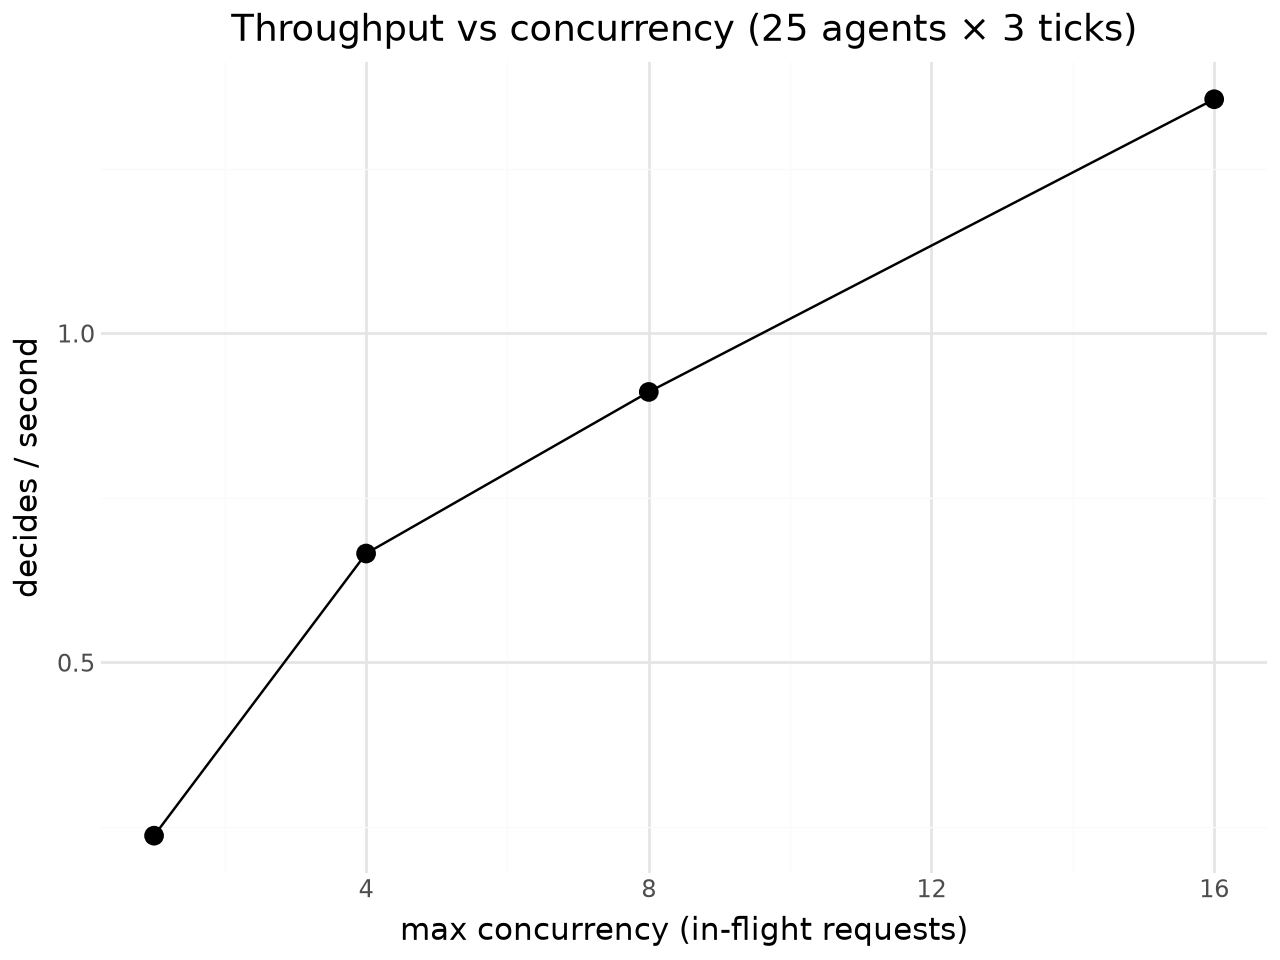

In [6]:
(ggplot(sweep, aes('concurrency', 'decides_per_s'))
 + geom_line() + geom_point(size=3)
 + labs(title=f'Throughput vs concurrency ({N_AGENTS} agents × {TICKS} ticks)',
        x='max concurrency (in-flight requests)', y='decides / second')
 + theme_minimal())

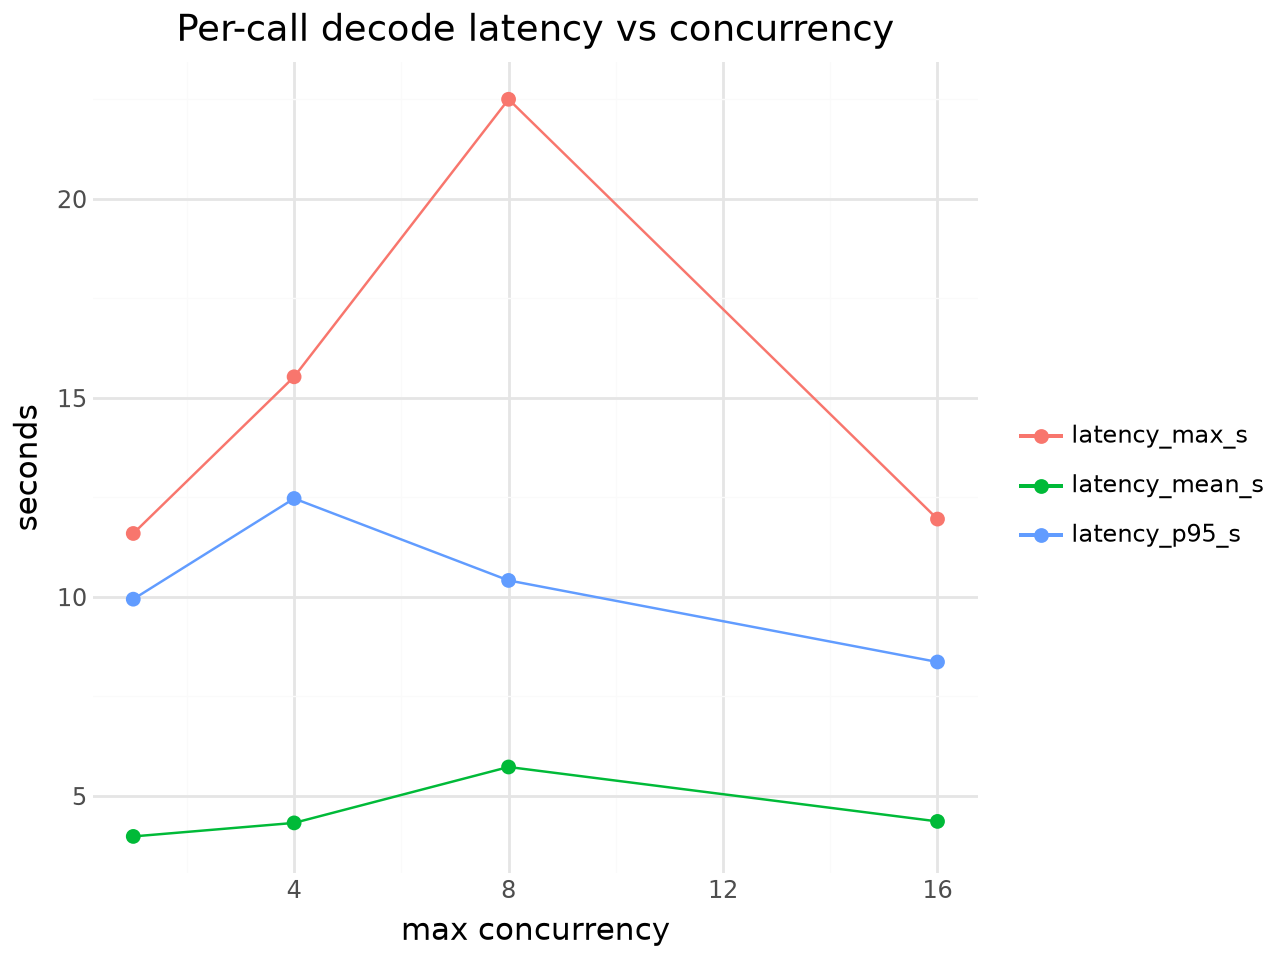

In [7]:
lat = sweep.melt(id_vars='concurrency',
                 value_vars=['latency_mean_s', 'latency_p95_s', 'latency_max_s'],
                 var_name='stat', value_name='seconds')
(ggplot(lat, aes('concurrency', 'seconds', color='stat'))
 + geom_line() + geom_point(size=2)
 + labs(title='Per-call decode latency vs concurrency', x='max concurrency',
        y='seconds', color='')
 + theme_minimal())

## 4. Per-tick trajectory (R15)

Throughput is logged *per tick*, not just at endpoint — the `tick_metrics` event stream is the trajectory view that the P5 divergence metric will sit beside. Read back from the last swept run's SQLite log.

 tick  n_calls  decide_wall_s  total_tokens  latency_mean_s  retries  failures
    0       25      18.995658         11550        4.028749        0         0
    1       25      19.760646         16168        5.347168        0         0
    2       25      16.572254         16027        3.694544        0         0


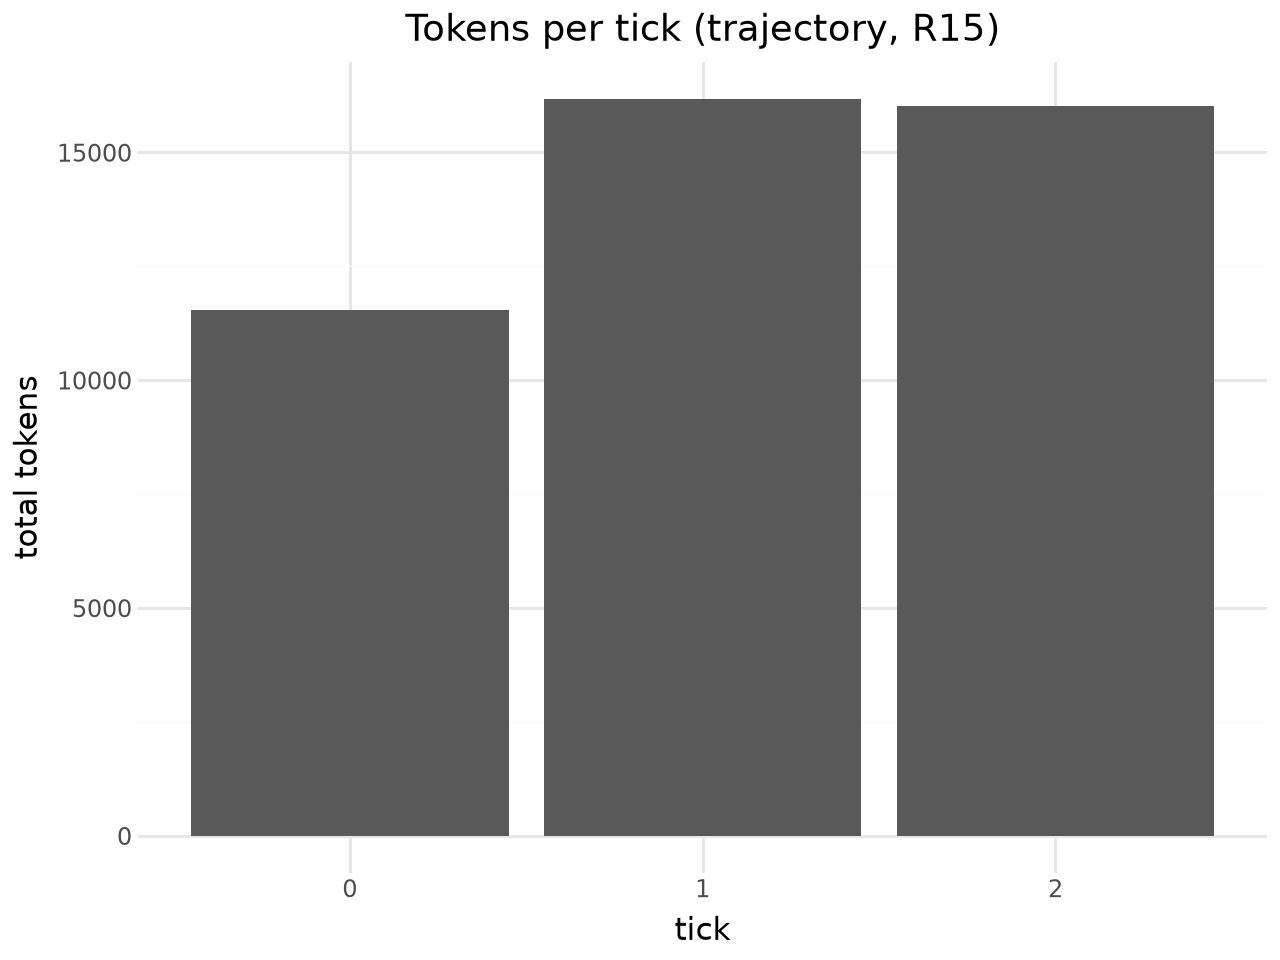

In [8]:
reopened = RunLog.open(os.path.join(DB_DIR, f'phase3_c{CONCURRENCY_SWEEP[-1]:02d}.db'))
tm = pd.DataFrame([e['payload'] for e in reopened.events(r.run_id, event_type=EVENT_TICK_METRICS)])
print(tm[['tick', 'n_calls', 'decide_wall_s', 'total_tokens', 'latency_mean_s', 'retries', 'failures']].to_string(index=False))
(ggplot(tm, aes('factor(tick)', 'total_tokens'))
 + geom_col()
 + labs(title='Tokens per tick (trajectory, R15)', x='tick', y='total tokens')
 + theme_minimal())

## Verdict

**DoD met** when: `N_AGENTS` (20–30) agents complete `TICKS` ticks with `failures == 0` across every sweep config; each decide logs a latency + token count (§1); `decides_per_s` rises with the concurrency cap (§2–3); and the per-tick `tick_metrics` trajectory reopens from disk (§4). The concurrency knob is a recorded run parameter (`config['scheduler']`, R17) and the model+provider are pinned per run (`config['provider']`, R6). R5 is honoured structurally — the scheduler caps in-flight requests and never shares reasoning across agents.

The vLLM continuous-batching executor (`SchedulerConfig(executor='batch')`) is a deferred seam: on the 16 GB local card the 32B persona model doesn't fit, and ADR 0002 keeps it on managed OpenRouter until P5, where local-GPU batching gets benchmarked against these managed numbers (ADR 0009).